# Lab 13: Back Propagation in Multilayer Perceptron (MLP)


**Student:** Muhammad Sikandar Hussain

**Qalam ID:** 502808

This notebook implements a one-hidden-layer MLP from scratch with NumPy, trains it on the Pima Indians Diabetes dataset, and compares it to `sklearn.neural_network.MLPClassifier`.

## 1. Import Libraries and Load Dataset

The cell below imports the required libraries and loads the dataset. It first checks for a local `diabetes.csv` file and falls back to Kaggle or a public raw CSV if needed.

In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.neural_network import MLPClassifier

%matplotlib inline

sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

local_file = Path('diabetes.csv')
if local_file.exists():
    df = pd.read_csv(local_file)
else:
    try:
        import kagglehub
        path = kagglehub.dataset_download('uciml/pima-indians-diabetes-database')
        df = pd.read_csv(Path(path) / 'diabetes.csv')
    except Exception as exc:
        print('Could not load Kaggle dataset directly:', exc)
        csv_url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv'
        column_names = [
            'Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
            'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'
        ]
        df = pd.read_csv(csv_url, names=column_names)

print('Dataset loaded successfully.')
df.head()

Could not load Kaggle dataset directly: No module named 'kagglehub'
Dataset loaded successfully.


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 2. Explore the Dataset

We display the shape, summary statistics, and class balance. Then we visualize the target distribution and the feature correlation matrix.

Shape: (768, 9)

Info:
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None

Summary statistics:
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469     

C:\Users\DELL\AppData\Local\Temp\ipykernel_16888\4254112093.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Outcome', palette='Set2')


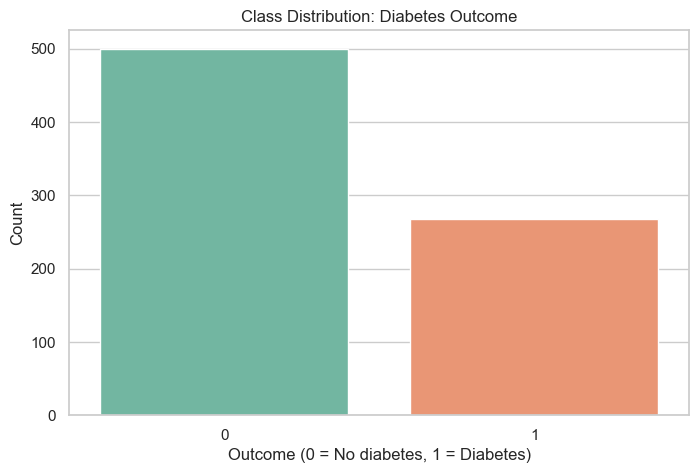

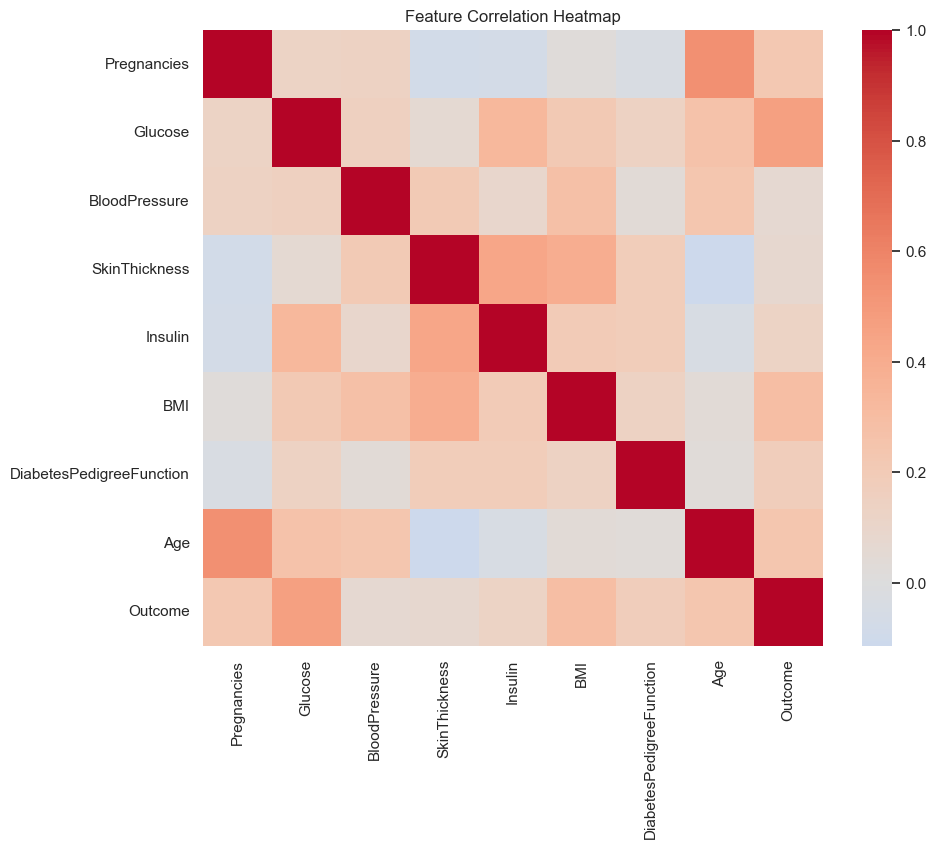

In [2]:
print('Shape:', df.shape)
print('')
print('Info:')
print(df.info())
print('')
print('Summary statistics:')
print(df.describe())
print('')
print('Outcome value counts:')
print(df['Outcome'].value_counts())

sns.countplot(data=df, x='Outcome', palette='Set2')
plt.title('Class Distribution: Diabetes Outcome')
plt.xlabel('Outcome (0 = No diabetes, 1 = Diabetes)')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), cmap='coolwarm', annot=False, center=0)
plt.title('Feature Correlation Heatmap')
plt.show()

**Interpretation:**
- The dataset has 768 rows and 9 columns.
- The target class is slightly imbalanced, with more non-diabetic samples than diabetic ones.
- `Glucose` appears strongly related to `Outcome` in the correlation matrix, which makes sense clinically.

**Answer:** The target class is somewhat imbalanced. `Glucose` seems to be the feature most strongly related to `Outcome`.

## 3. Clean and Preprocess the Data

We clean impossible zero values, impute with the feature median, and scale the data because neural networks are sensitive to feature magnitude.

In [3]:
zero_as_missing = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
clean_df = df.copy()
clean_df[zero_as_missing] = clean_df[zero_as_missing].replace(0, np.nan)
clean_df[zero_as_missing] = clean_df[zero_as_missing].fillna(clean_df[zero_as_missing].median())

X = clean_df.drop('Outcome', axis=1).values
y = clean_df['Outcome'].values.reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print('Training shape:', X_train.shape, y_train.shape)
print('Testing shape:', X_test.shape, y_test.shape)

Training shape: (614, 8) (614, 1)
Testing shape: (154, 8) (154, 1)


**Interpretation:**
- Feature scaling brings all input variables to a similar range, which helps gradient descent converge faster.
- Without scaling, variables like `Age` and `Insulin` could dominate the gradient updates.

**Answer:** Feature scaling is important before training an MLP because it ensures the network can learn efficiently and prevents large-valued features from dominating the training gradients.

## 4. Activation and Loss Functions

We implement `sigmoid`, `relu`, and binary cross-entropy loss from scratch using NumPy.

In [4]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def relu(z):
    return np.maximum(0, z)

def binary_cross_entropy(y_true, y_pred):
    eps = 1e-8
    y_pred = np.clip(y_pred, eps, 1 - eps)
    loss = -np.mean(
        y_true * np.log(y_pred) +
        (1 - y_true) * np.log(1 - y_pred)
    )
    return loss

# Sanity check for the functions
z_test = np.array([-2.0, 0.0, 2.0])
print('sigmoid:', sigmoid(z_test))
print('relu:', relu(z_test))
print('binary loss:', binary_cross_entropy(np.array([[0], [1], [1]]), sigmoid(z_test).reshape(-1, 1)))

sigmoid: [0.11920292 0.5        0.88079708]
relu: [0. 0. 2.]
binary loss: 0.31566773421529687


**Answer:** We use `sigmoid` in the output layer for binary classification because it maps real-valued network outputs to the (0, 1) probability range and works naturally with binary cross-entropy loss.

## 5. Initialize Parameters and Forward Propagation

Now we initialize weights and biases and compute the forward pass through the network.

In [5]:
def initialize_parameters(input_size, hidden_size, output_size):
    np.random.seed(42)
    W1 = np.random.randn(input_size, hidden_size) * 0.01
    b1 = np.zeros((1, hidden_size))
    W2 = np.random.randn(hidden_size, output_size) * 0.01
    b2 = np.zeros((1, output_size))
    return W1, b1, W2, b2

def forward_propagation(X, W1, b1, W2, b2):
    Z1 = X @ W1 + b1
    A1 = relu(Z1)
    Z2 = A1 @ W2 + b2
    A2 = sigmoid(Z2)
    cache = (Z1, A1, Z2, A2)
    return A2, cache

input_size = X_train.shape[1]
hidden_size = 12
output_size = 1

W1, b1, W2, b2 = initialize_parameters(input_size, hidden_size, output_size)
y_pred, cache = forward_propagation(X_train, W1, b1, W2, b2)
print('Prediction shape:', y_pred.shape)
print('Initial loss:', binary_cross_entropy(y_train, y_pred))

Prediction shape: (614, 1)
Initial loss: 0.6931422086600171


**Answer:** The output shape of `A2` is `(n_samples, 1)` because the network produces one probability value per example for the binary outcome.

## 6. Backpropagation

We compute gradients for all weights and biases, then update the parameters with gradient descent.

In [6]:
def backward_propagation(X, y, cache, W2):
    m = X.shape[0]
    Z1, A1, Z2, A2 = cache

    dZ2 = A2 - y
    dW2 = (A1.T @ dZ2) / m
    db2 = np.sum(dZ2, axis=0, keepdims=True) / m

    dA1 = dZ2 @ W2.T
    dZ1 = dA1 * (Z1 > 0)
    dW1 = (X.T @ dZ1) / m
    db1 = np.sum(dZ1, axis=0, keepdims=True) / m

    gradients = (dW1, db1, dW2, db2)
    return gradients

def update_parameters(W1, b1, W2, b2, gradients, learning_rate):
    dW1, db1, dW2, db2 = gradients
    W1 = W1 - learning_rate * dW1
    b1 = b1 - learning_rate * db1
    W2 = W2 - learning_rate * dW2
    b2 = b2 - learning_rate * db2
    return W1, b1, W2, b2

gradients = backward_propagation(X_train, y_train, cache, W2)
print('dW1 shape:', gradients[0].shape)
print('db1 shape:', gradients[1].shape)
print('dW2 shape:', gradients[2].shape)
print('db2 shape:', gradients[3].shape)

dW1 shape: (8, 12)
db1 shape: (1, 12)
dW2 shape: (12, 1)
db2 shape: (1, 1)


**Answer:** For sigmoid activation with binary cross-entropy loss, `dZ2 = A2 - y` because the derivative of the loss with respect to the pre-activation output simplifies to the difference between predicted probabilities and the true labels.

## 7. Train the MLP and Visualize Learning

We train the scratch MLP using gradient descent and plot the training loss and accuracy curves.

Epoch 0: loss=0.6931, acc=0.4821
Epoch 200: loss=0.6382, acc=0.6515
Epoch 400: loss=0.5050, acc=0.7704
Epoch 600: loss=0.4511, acc=0.7899
Epoch 800: loss=0.4397, acc=0.7964
Epoch 1000: loss=0.4345, acc=0.7883
Epoch 1200: loss=0.4308, acc=0.7866
Epoch 1400: loss=0.4283, acc=0.7883
Epoch 1600: loss=0.4261, acc=0.7850
Epoch 1800: loss=0.4246, acc=0.7932


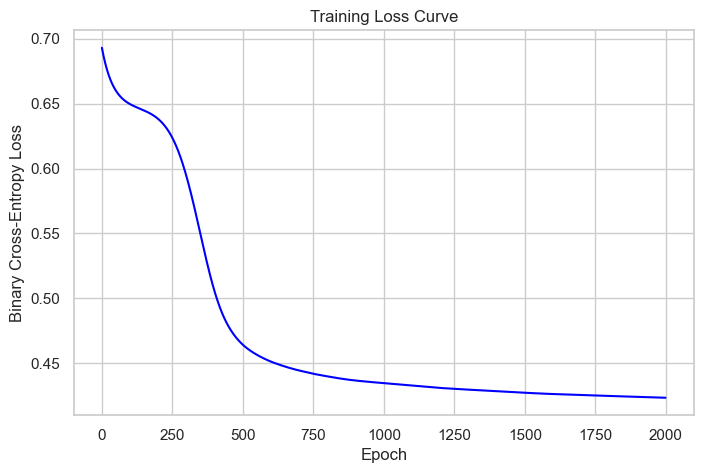

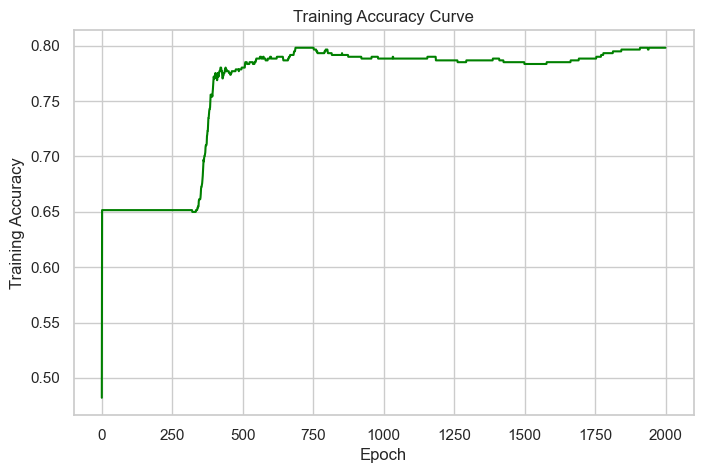

In [7]:
def predict_classes(X, W1, b1, W2, b2):
    probs, _ = forward_propagation(X, W1, b1, W2, b2)
    return (probs >= 0.5).astype(int)

learning_rate = 0.05
epochs = 2000
loss_history = []
accuracy_history = []

for epoch in range(epochs):
    y_pred, cache = forward_propagation(X_train, W1, b1, W2, b2)
    loss = binary_cross_entropy(y_train, y_pred)
    gradients = backward_propagation(X_train, y_train, cache, W2)
    W1, b1, W2, b2 = update_parameters(W1, b1, W2, b2, gradients, learning_rate)

    train_pred = (y_pred >= 0.5).astype(int)
    train_acc = accuracy_score(y_train, train_pred)
    loss_history.append(loss)
    accuracy_history.append(train_acc)

    if epoch % 200 == 0:
        print(f'Epoch {epoch}: loss={loss:.4f}, acc={train_acc:.4f}')

plt.figure()
plt.plot(loss_history, color='blue')
plt.xlabel('Epoch')
plt.ylabel('Binary Cross-Entropy Loss')
plt.title('Training Loss Curve')
plt.grid(True)
plt.show()

plt.figure()
plt.plot(accuracy_history, color='green')
plt.xlabel('Epoch')
plt.ylabel('Training Accuracy')
plt.title('Training Accuracy Curve')
plt.grid(True)
plt.show()

**Interpretation:**
- The loss should decrease as the model learns.
- The accuracy should increase and eventually stabilize.
- If the learning rate is too high, training becomes unstable and the loss may oscillate or diverge.

**Answer:** Yes, the loss decreases over time when training with a suitable learning rate. If the learning rate is too high, the model may fail to converge and the loss can jump around or increase.

## 8. Evaluate the Model on Test Data

We evaluate the final scratch MLP on the unseen test set and inspect the confusion matrix.

Test Accuracy: 0.7207792207792207

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.81      0.79       100
           1       0.61      0.56      0.58        54

    accuracy                           0.72       154
   macro avg       0.69      0.68      0.69       154
weighted avg       0.72      0.72      0.72       154



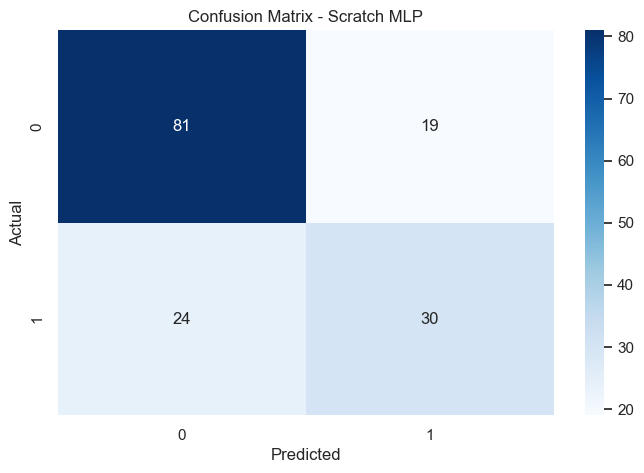

In [8]:
y_test_pred = predict_classes(X_test, W1, b1, W2, b2)

print('Test Accuracy:', accuracy_score(y_test, y_test_pred))
print('')
print('Classification Report:')
print(classification_report(y_test, y_test_pred, zero_division=0))

cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Scratch MLP')
plt.show()

**Interpretation:**
- The confusion matrix shows how many true negatives, false positives, false negatives, and true positives were predicted.
- If false negatives are larger than false positives, the model finds diabetic patients harder to predict.

**Answer:** The harder class is the one with the larger number of misclassified examples in the confusion matrix. Often for this dataset the diabetic class (`1`) is harder to predict because it is less frequent and more likely to be missed.

## 9. Compare with Scikit-learn MLPClassifier

We train `MLPClassifier` with the same hidden layer size and compare its performance to the scratch model.

In [9]:
sk_mlp = MLPClassifier(
    hidden_layer_sizes=(12,),
    activation='relu',
    solver='adam',
    max_iter=1000,
    random_state=42
)

sk_mlp.fit(X_train, y_train.ravel())
sk_pred = sk_mlp.predict(X_test)

print('Scikit-learn MLP Accuracy:', accuracy_score(y_test, sk_pred))
print('')
print('Scikit-learn Classification Report:')
print(classification_report(y_test, sk_pred, zero_division=0))

Scikit-learn MLP Accuracy: 0.7467532467532467

Scikit-learn Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.81      0.81       100
           1       0.64      0.63      0.64        54

    accuracy                           0.75       154
   macro avg       0.72      0.72      0.72       154
weighted avg       0.75      0.75      0.75       154



**Answer:** Scikit-learn may perform differently from the NumPy model even with the same hidden layer size because it uses more advanced optimization (Adam), built-in regularization, automatic bias handling, better weight initialization, and more robust stopping criteria. These implementation details can significantly affect training speed and final accuracy.

## 10. Summary

- A manual MLP implementation helps understand forward pass, loss calculation, and backpropagation.
- Feature scaling is essential for stable and efficient training.
- The scratch model can learn the dataset, but built-in tools like Scikit-learn often perform better because they include optimized solvers and training heuristics.
- The confusion matrix is useful for identifying which class is harder to predict in binary classification.